In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# ---------------------------------------------------------
# Load Aerodynamic Parameters (Extracted from your config)
# ---------------------------------------------------------
# Lift & Drag
CL_0 = 0.5
CL_alpha = 4.982       # per rad
CL_delta_e = 0.435     # per rad
CD0 = 0.0175
k = 0.06

# Longitudinal (Pitch)
Cm_0 = -0.025
Cm_alpha = -1.246      # per rad
Cm_delta_e = -1.46     # per rad

# Directional (Yaw - N)
Cn_beta = 1.75         # per rad
Cn_delta_r = -1.0      # per rad
Cn_delta_a = -0.125    # per rad

# Lateral (Roll - L, noted as Cr in your config)
Cl_beta = -1.3         # per rad
Cl_delta_a = 0.05     # per rad
Cl_delta_r = 0.3      # per rad

# Side Force (Y)
Cy_beta = -1.5         # per rad
Cy_delta_a = -0.33      # per rad
Cy_delta_r = 0.25       # per rad

# Control limits (degrees)
lim_de = [-25, 10]
lim_da = [-25, 25]
lim_dr = [-30, 30]

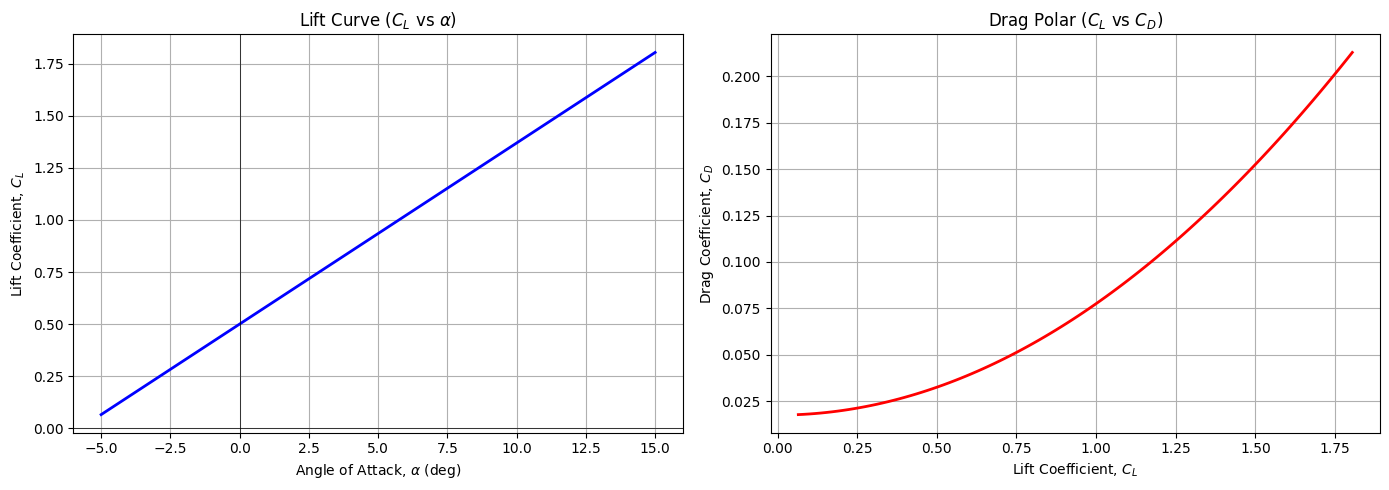

In [6]:
# Generate arrays for Angle of Attack (alpha) from -5 to 15 degrees
alpha_deg = np.linspace(-5, 15, 100)
alpha_rad = np.radians(alpha_deg)

# Calculate CL (clean configuration, delta_e = 0)
CL = CL_0 + CL_alpha * alpha_rad

# Calculate CD
CD = CD0 + k * CL**2

# Plotting Basic Aerodynamics
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Lift Curve
axs[0].plot(alpha_deg, CL, 'b-', linewidth=2)
axs[0].set_title('Lift Curve ($C_L$ vs $\\alpha$)')
axs[0].set_xlabel('Angle of Attack, $\\alpha$ (deg)')
axs[0].set_ylabel('Lift Coefficient, $C_L$')
axs[0].grid(True)
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].axvline(0, color='black', linewidth=0.5)

# Plot 2: Drag Polar
axs[1].plot(CL, CD, 'r-', linewidth=2)
axs[1].set_title('Drag Polar ($C_L$ vs $C_D$)')
axs[1].set_xlabel('Lift Coefficient, $C_L$')
axs[1].set_ylabel('Drag Coefficient, $C_D$')
axs[1].grid(True)

plt.tight_layout()
plt.show()

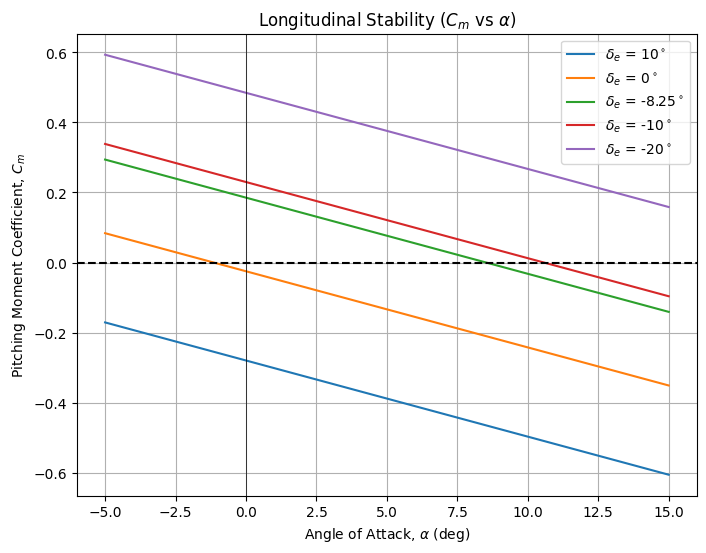

In [9]:
# Sweep elevator deflections to see trim points (Cm = 0)
elevators_deg = [10, 0, -8.25, -10, -20]

fig, ax = plt.subplots(figsize=(8, 6))

for de in elevators_deg:
    de_rad = np.radians(de)
    # Calculate Cm
    Cm = Cm_0 + Cm_alpha * alpha_rad + Cm_delta_e * de_rad
    ax.plot(alpha_deg, Cm, label=f'$\\delta_e$ = {de}$^\\circ$')

ax.set_title('Longitudinal Stability ($C_m$ vs $\\alpha$)')
ax.set_xlabel('Angle of Attack, $\\alpha$ (deg)')
ax.set_ylabel('Pitching Moment Coefficient, $C_m$')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True)
ax.legend()

plt.show()

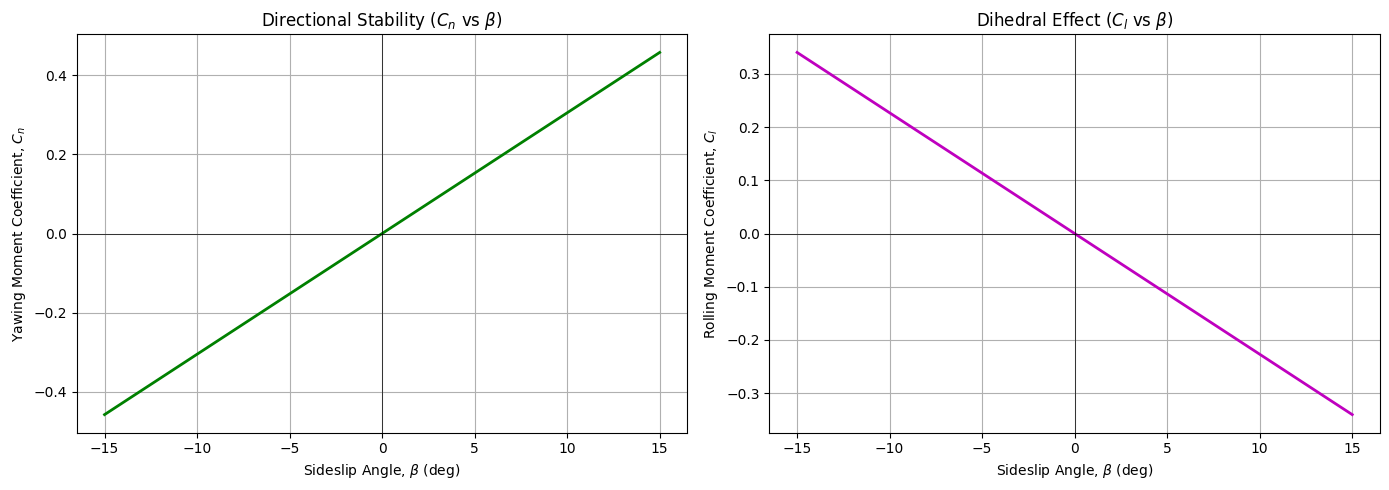

In [5]:
# Generate arrays for Sideslip (beta) from -15 to 15 degrees
beta_deg = np.linspace(-15, 15, 100)
beta_rad = np.radians(beta_deg)

# Calculate Cn and Cl (clean configuration, no control deflection)
Cn = Cn_beta * beta_rad
Cl = Cl_beta * beta_rad

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weathercock Stability (Cn vs Beta)
axs[0].plot(beta_deg, Cn, 'g-', linewidth=2)
axs[0].set_title('Directional Stability ($C_n$ vs $\\beta$)')
axs[0].set_xlabel('Sideslip Angle, $\\beta$ (deg)')
axs[0].set_ylabel('Yawing Moment Coefficient, $C_n$')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].axvline(0, color='black', linewidth=0.5)
axs[0].grid(True)
# Note: A positive slope (Cn_beta > 0) means the aircraft is directionally stable.

# Plot 2: Dihedral Effect (Cl vs Beta)
axs[1].plot(beta_deg, Cl, 'm-', linewidth=2)
axs[1].set_title('Dihedral Effect ($C_l$ vs $\\beta$)')
axs[1].set_xlabel('Sideslip Angle, $\\beta$ (deg)')
axs[1].set_ylabel('Rolling Moment Coefficient, $C_l$')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].axvline(0, color='black', linewidth=0.5)
axs[1].grid(True)
# Note: A negative slope (Cl_beta < 0) means the aircraft is laterally stable.

plt.tight_layout()
plt.show()

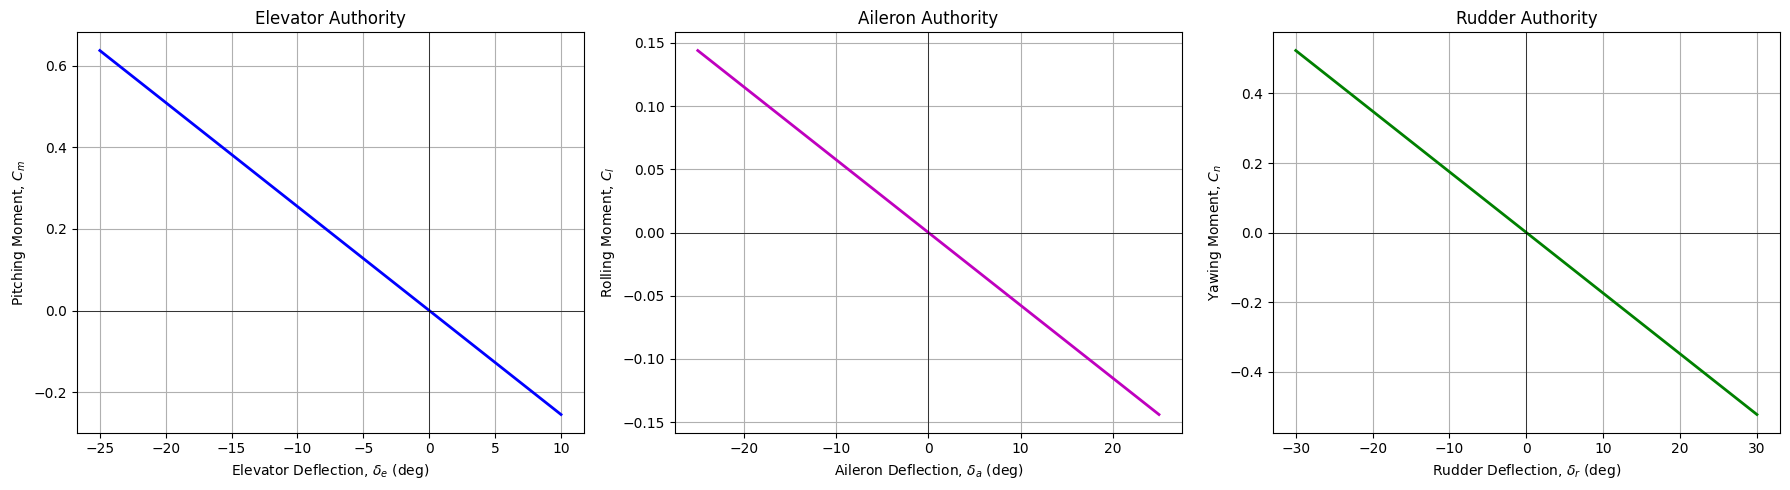

In [6]:
# Sweep control surface deflections from their min to max limits
de_sweep = np.linspace(lim_de[0], lim_de[1], 100)
da_sweep = np.linspace(lim_da[0], lim_da[1], 100)
dr_sweep = np.linspace(lim_dr[0], lim_dr[1], 100)

Cm_auth = Cm_delta_e * np.radians(de_sweep)
Cl_auth = Cl_delta_a * np.radians(da_sweep)
Cn_auth = Cn_delta_r * np.radians(dr_sweep)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Elevator Authority
axs[0].plot(de_sweep, Cm_auth, 'b-', linewidth=2)
axs[0].set_title('Elevator Authority')
axs[0].set_xlabel('Elevator Deflection, $\\delta_e$ (deg)')
axs[0].set_ylabel('Pitching Moment, $C_m$')
axs[0].grid(True)

# Aileron Authority
axs[1].plot(da_sweep, Cl_auth, 'm-', linewidth=2)
axs[1].set_title('Aileron Authority')
axs[1].set_xlabel('Aileron Deflection, $\\delta_a$ (deg)')
axs[1].set_ylabel('Rolling Moment, $C_l$')
axs[1].grid(True)

# Rudder Authority
axs[2].plot(dr_sweep, Cn_auth, 'g-', linewidth=2)
axs[2].set_title('Rudder Authority')
axs[2].set_xlabel('Rudder Deflection, $\\delta_r$ (deg)')
axs[2].set_ylabel('Yawing Moment, $C_n$')
axs[2].grid(True)

for ax in axs:
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

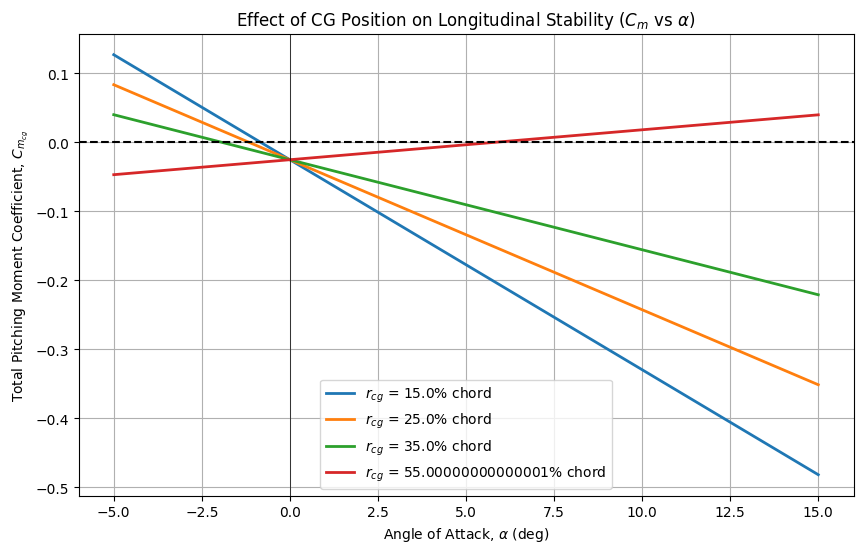

In [8]:
# %% [Cell 6: Effect of CG Shift on Static Margin]
# Assume the config's Cm data is referenced at r_ac = 0.25
r_ac = 0.25

# Let's test a few different CG positions (as % of chord)
# Forward CG (Stable), Nominal CG, Aft CG (Less Stable), Far Aft (Unstable)
cg_positions = [0.15, 0.25, 0.35, 0.55] 

fig, ax = plt.subplots(figsize=(10, 6))

for r_cg in cg_positions:
    # 1. Calculate Lift
    CL = CL_0 + CL_alpha * alpha_rad
    
    # 2. Calculate the baseline Pitching Moment at the AC
    Cm_ac = Cm_0 + Cm_alpha * alpha_rad
    
    # 3. Transfer the moment to the new CG
    # The moment arm is (r_cg - r_ac). 
    # If CG is behind AC (r_cg > r_ac), upward Lift creates a positive (pitch-up) moment.
    delta_Cm = CL * (r_cg - r_ac)
    
    # Total Cm at the specific CG
    Cm_cg = Cm_ac + delta_Cm
    
    # Plotting
    ax.plot(alpha_deg, Cm_cg, linewidth=2, label=f'$r_{{cg}}$ = {r_cg*100}% chord')

ax.set_title('Effect of CG Position on Longitudinal Stability ($C_m$ vs $\\alpha$)')
ax.set_xlabel('Angle of Attack, $\\alpha$ (deg)')
ax.set_ylabel('Total Pitching Moment Coefficient, $C_{m_{cg}}$')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True)
ax.legend()

plt.show()